# RTDA — the performance scan

One network, three implementations, five scales. This notebook answers **where the
time goes and how it scales**, which the accuracy notebooks do not:

| | `aie_batch` fp32 | `aie_batch` bf16 | `pl_fixed` |
|---|---|---|---|
| where | AIE-ML array | AIE-ML array | PL fabric |
| shape | 8 tracks per graph iteration | same | 1 event per kernel call |
| what limits it | fixed cost per `graph.run()` | same | *this notebook finds out* |

It reads `results/<impl>/{hw,hw_emu}/scan.csv` + `scan_meta.txt`, written by
`host_scan.exe`. Nothing here reads `run_info.txt` or `track_means_all.txt` —
those belong to the accuracy runs and to `rtda_compare.ipynb`.

**Three things it is built to settle:**

1. **The AIE fixed launch cost.** `results/README.md` records a four-point sweep
   fitting `total = 583 us + 595.6 ns x tracks`, but those four numbers are
   hardcoded in a cell of `rtda_reference.ipynb` and predate the current host.
   Here they are measured, with repeats, and the launch count is swept directly.
2. **The PL bottleneck.** The board reports 5.71 ms/event; csynth predicts 2.11 ms
   of fabric. The gap sits inside a timer spanning enqueue *and* wait, so it could
   be driver overhead or slow fabric. The `tracks_per_call` sweep separates them.
3. **Spread.** Every performance number in the repo is a single run. These are
   repeated, and reported as min / median / max.

> **Prerequisite:** at least one `scan.csv` under `results/`. With none, every
> section below says so and stops rather than inventing anything. It renders
> usefully with only one implementation present.

## 0. Setup

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
pd.set_option('display.width', 140)

REPO = Path.cwd()
while not (REPO / 'model' / 'weights_fp32').is_dir() and REPO != REPO.parent:
    REPO = REPO.parent
RESULTS = REPO / 'results'
OUTD    = REPO / 'analysis' / 'out'
OUTD.mkdir(parents=True, exist_ok=True)
print('repo   :', REPO)

# ---------------------------------------------------------------------------
# THE IMPLEMENTATIONS, and their colours.
#
# Same order, labels and colours as rtda_compare.ipynb, deliberately: a reader
# moving between the accuracy notebook and this one must not have to re-learn
# which colour is which implementation. Validated as a categorical palette --
# worst adjacent pair 21.1 dE under protanopia against a target of 8, so the
# three stay distinguishable in print and under colour-vision deficiency.
# ---------------------------------------------------------------------------
IMPLS  = ('aie_fp32', 'aie_bf16', 'pl_fixed')
LABEL  = {'aie_fp32': 'AIE fp32', 'aie_bf16': 'AIE bf16',
          'pl_fixed': 'PL ap_fixed<16,3>'}
COL    = {'aie_fp32': '#1f77b4', 'aie_bf16': '#d62728', 'pl_fixed': '#9467bd'}
TARGETS = ('hw', 'hw_emu')

# Geometry, matching both hosts and the graph.
TRACKS_PER_EVENT, ITER_PER_EVENT, BATCH = 50, 7, 8
MACS_PER_TRACK = 264192          # 14 dense layers
OPS_PER_MAC    = 2               # multiply + add, the convention run_info.txt uses

# The PL fabric reference. NOT measurable by the host and not in the CSV:
# csynth reports TrackLoop iteration latency 6335 cycles, and the xclbin was
# linked --clock.defaultFreqHz 150000000 (confirmed with `xclbinutil --info`).
# It lives here, once, so every panel below quotes the same figure.
PL_CSYNTH_CYCLES, PL_CLOCK_MHZ = 6335, 150.0
PL_CSYNTH_US_PER_TRACK = PL_CSYNTH_CYCLES / PL_CLOCK_MHZ       # 42.23 us

# The phase stack is an ORDERED PIPELINE, not four independent categories, so it
# gets one hue light->dark rather than four hues. That also keeps all three
# categorical colours free to mean "implementation" everywhere in this notebook.
PHASES      = ['us_stage', 'us_h2d', 'us_kernel', 'us_d2h']
PHASE_LABEL = {'us_stage':  'host staging',
               'us_h2d':    'H2D (AIE: issue only)',
               'us_kernel': 'kernel / graph.run',
               'us_d2h':    'D2H (AIE: un-overlapped tail)'}
PHASE_COL   = {'us_stage': '#9ecae1', 'us_h2d': '#6baed6',
               'us_kernel': '#3182bd', 'us_d2h': '#08519c'}

# ---------------------------------------------------------------------------
# Plot style: recessive grid and axes, thin marks, no top/right spines. An
# explicit white figure face rather than transparent, so a PNG dropped into a
# dark-themed page still reads as a panel instead of inheriting its background.
# ---------------------------------------------------------------------------
mpl.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'savefig.facecolor': 'white', 'savefig.dpi': 150, 'figure.dpi': 110,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': '#9aa0a6', 'axes.labelcolor': '#202124',
    'axes.titlesize': 11, 'axes.titleweight': 'bold', 'axes.titlelocation': 'left',
    'axes.labelsize': 9.5, 'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'xtick.color': '#5f6368', 'ytick.color': '#5f6368', 'text.color': '#202124',
    'grid.color': '#dadce0', 'grid.linewidth': 0.6, 'axes.grid': True,
    'axes.axisbelow': True, 'lines.linewidth': 2, 'lines.markersize': 6,
    'legend.frameon': False, 'legend.fontsize': 9,
    'figure.constrained_layout.use': True,
})

def style(ax, title=None, xlabel=None, ylabel=None, note=None):
    """Titles/labels in one place so every panel is annotated the same way."""
    if title:  ax.set_title(title, pad=10)
    if xlabel: ax.set_xlabel(xlabel)
    if ylabel: ax.set_ylabel(ylabel)
    if note:   ax.text(0.0, -0.19, note, transform=ax.transAxes,
                       fontsize=8, color='#5f6368', va='top')
    return ax

def save(fig, name):
    p = OUTD / name
    fig.savefig(p, bbox_inches='tight')
    print('  wrote', p.relative_to(REPO))

def md_table(df):
    """DataFrame -> markdown. Hand-rolled rather than df.to_markdown(), which
    needs `tabulate`: this notebook deliberately runs on the numpy + pandas +
    matplotlib that envaie2 already has, so a fresh checkout can produce the
    report without an install step."""
    cols = [str(c) for c in df.columns]
    out = ['| ' + ' | '.join(cols) + ' |',
           '|' + '|'.join('---' for _ in cols) + '|']
    for _, row in df.iterrows():
        out.append('| ' + ' | '.join(str(v) for v in row.tolist()) + ' |')
    return '\n'.join(out)

repo   : /home/synthara/VersalPrjs/LDRD/final_rtda/rtda_demo


In [2]:
def read_kv(path):
    """key=value -> dict. Numeric where it parses; '' stays None, because an empty
    field means 'this implementation cannot measure that', not zero."""
    out = {}
    if not Path(path).exists():
        return out
    for line in Path(path).read_text().splitlines():
        if '=' not in line:
            continue
        k, v = line.split('=', 1)
        v = v.strip()
        if v == '':
            out[k] = None
            continue
        try:
            out[k] = float(v) if ('.' in v or 'e' in v.lower()) else int(v)
        except ValueError:
            out[k] = v
    return out


def load_scan():
    """Every scan on disk. Discovers rather than assumes -- a missing
    implementation or target is simply absent from the result, and every section
    below is written to cope with that."""
    runs = []
    for impl in IMPLS:
        for tgt in TARGETS:
            d = RESULTS / impl / tgt
            csv = d / 'scan.csv'
            if not csv.exists():
                continue
            df = pd.read_csv(csv)
            df['impl'] = impl          # trust the PATH, not the file: see below
            df['target'] = tgt
            meta = read_kv(d / 'scan_meta.txt')
            calls = {}
            for cf in sorted(d.glob('scan_calls_*.csv')):
                calls[int(cf.stem.split('_')[-1])] = pd.read_csv(cf)
            runs.append(dict(impl=impl, target=tgt, dir=d, df=df,
                             meta=meta, calls=calls))
    return runs


RUNS = load_scan()
SCAN = pd.concat([r['df'] for r in RUNS], ignore_index=True) if RUNS else pd.DataFrame()
META = {(r['impl'], r['target']): r['meta'] for r in RUNS}


def primary(df):
    """The rows directly comparable ACROSS implementations.

    AIE: mode=gmio with launches=1, i.e. the whole event count in one
    graph.run() -- exactly what host_batch.exe does.
    PL:  mode=fresh, one kernel call per event with a new xrt::run -- exactly
    what host_split.exe does.

    Excludes the launch-count and tracks-per-call diagnostics, which are
    deliberately NOT like-for-like and get their own sections."""
    if df.empty:
        return df
    m = (((df['mode'] == 'gmio') & (df['launches'] == 1)) |
         (df['mode'] == 'fresh')) & (df['events'] > 0)
    return df[m]


def agg(df, col, by='events'):
    """min / median / max over repeats. Every performance figure in this repo
    before now was a single run; this is the whole reason for reps."""
    if df.empty or col not in df:
        return pd.DataFrame()
    g = df.groupby(by)[col].agg(['min', 'median', 'max', 'count'])
    return g.sort_index()


def impl_runs(target='hw'):
    """Implementations present for a target, in canonical order."""
    return [r for i in IMPLS for r in RUNS if r['impl'] == i and r['target'] == target]

print(f'{len(RUNS)} scan(s) found')

3 scan(s) found


## 1. What ran

In [3]:
if not RUNS:
    print('No scan.csv anywhere under results/.')
    print()
    print('Produce one:   make scan_host FLOW=pl_fixed      # or FLOW=aie_batch')
    print('               (run host_scan.exe on the board -- RUNBOOK.md PHASE 7)')
    print('               make collect_scan FROM=/mnt/usb FLOW=pl_fixed TARGET=hw')
    print()
    print('Every section below is a no-op until then. Nothing here invents data.')
else:
    rows = []
    for r in RUNS:
        d, m = r['df'], r['meta']
        p = primary(d)
        rows.append({
            'impl': LABEL[r['impl']], 'target': r['target'],
            'variant': m.get('variant', '?'),
            'events': '/'.join(str(int(e)) for e in sorted(p['events'].unique())) or '-',
            'reps': int(m.get('reps', 0)),
            'rows': len(d),
            'xclbin': str(m.get('xclbin', '?')),
            'stim_ev': m.get('stimulus_events', '?'),
            'git': str(m.get('git_hash', '?')),
            'date_utc': str(m.get('date_utc', '?')),
        })
    print(pd.DataFrame(rows).to_string(index=False))

    # ---- the one sanity gate ------------------------------------------------
    # mean_checksum is a smoke value, not an accuracy number. It is checked for
    # exactly two things: it is not zero (a graph that produced nothing would
    # otherwise read as a very fast run) and it does not move between repeats of
    # the same point (which would mean the run was not deterministic and none of
    # the timings describe a single thing).
    print()
    bad = 0
    for r in RUNS:
        p = primary(r['df'])
        if p.empty:
            continue
        z = p[p['mean_checksum'] == 0]
        if len(z):
            print(f"  FAIL {LABEL[r['impl']]}/{r['target']}: "
                  f"{len(z)} row(s) with mean_checksum == 0 -- the device "
                  f"produced no output, so those timings are meaningless")
            bad += 1
        spread = p.groupby('events')['mean_checksum'].nunique()
        if (spread > 1).any():
            ev = list(spread[spread > 1].index)
            print(f"  WARN {LABEL[r['impl']]}/{r['target']}: mean_checksum varies "
                  f"across repeats at events={ev} -- the run is not deterministic")
            bad += 1
    if not bad:
        print('  checksum gate: PASS -- every point non-zero and stable across repeats')

    emu = [r for r in RUNS if r['target'] == 'hw_emu']
    if emu:
        print()
        print('  NOTE: ' + ', '.join(f"{LABEL[r['impl']]}" for r in emu) +
              ' is hw_emu. RTL simulation timings describe the simulator, not the'
              ' board -- they validate the host, they are not performance data.')

             impl target variant              events  reps  rows           xclbin  stim_ev     git             date_utc
         AIE fp32     hw    fp32 1/10/100/1000/10000     5    45 system_hw.xclbin    10000 4874a21 2037-12-10T12:51:38Z
         AIE bf16     hw    bf16 1/10/100/1000/10000     5    45 system_hw.xclbin    10000 4874a21 2037-09-26T12:41:43Z
PL ap_fixed<16,3>     hw  ap16_3 1/10/100/1000/10000     5    54 system_hw.xclbin    10000 4874a21 2035-04-23T19:39:05Z

  checksum gate: PASS -- every point non-zero and stable across repeats


## 2. How the cost scales

`us_execute` is the device time: for the PL the three real phases; for the AIE the
issue + `graph.run` + drain triple that *is* separable (see §3). Fitting

    us_execute = fixed + marginal x tracks

splits a per-invocation cost that does not shrink from a per-track cost that does.
That is the whole story of the 1-event point: at 50 tracks the AIE spends most of
its time on a cost that has nothing to do with the array.

  wrote analysis/out/scan_scaling.png


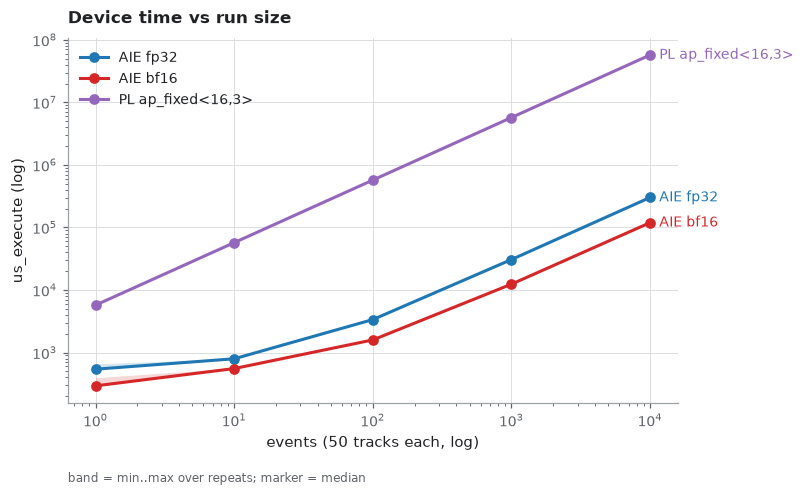


             impl  points  fixed us  marginal ns/track  worst resid %
         AIE fp32       5     485.0              602.0            5.0
         AIE bf16       5     406.2              237.8           42.4
PL ap_fixed<16,3>       5     -34.0           114405.8            0.7

  "fixed us" is paid once per invocation and is host/driver side --
  no change to the array or the fabric reduces it. "marginal" is what
  the design actually costs per track, and is what a big run
  converges to.


In [4]:
if not RUNS:
    print('(no data)')
else:
    fit_rows = []
    fig, ax = plt.subplots(figsize=(7.2, 4.4))
    for r in impl_runs('hw') or impl_runs('hw_emu'):
        impl = r['impl']
        p = primary(r['df'])
        if p.empty:
            continue
        g = agg(p, 'us_execute')
        ev = g.index.to_numpy(float)
        tr = ev * TRACKS_PER_EVENT
        med = g['median'].to_numpy(float)

        ax.plot(ev, med, marker='o', color=COL[impl], label=LABEL[impl], zorder=3)
        # min/max band rather than error bars: with 5 repeats the full range is
        # more honest than a standard deviation of five samples.
        ax.fill_between(ev, g['min'], g['max'], color=COL[impl], alpha=0.18, lw=0)
        # Direct label at the line end, so identity never rests on colour alone.
        ax.annotate(LABEL[impl], (ev[-1], med[-1]), textcoords='offset points',
                    xytext=(6, 0), color=COL[impl], fontsize=9, va='center')

        if len(ev) >= 2:
            A = np.column_stack([np.ones_like(tr), tr])
            (fixed, marginal), *_ = np.linalg.lstsq(A, med, rcond=None)
            pred = A @ (fixed, marginal)
            fit_rows.append({
                'impl': LABEL[impl], 'points': len(ev),
                'fixed us': round(fixed, 1),
                'marginal ns/track': round(marginal * 1e3, 1),
                'worst resid %': round(100 * np.max(np.abs(pred - med) / med), 1),
            })

    ax.set_xscale('log'); ax.set_yscale('log')
    style(ax, 'Device time vs run size',
          'events (50 tracks each, log)', 'us_execute (log)',
          'band = min..max over repeats; marker = median')
    ax.legend(loc='upper left')
    save(fig, 'scan_scaling.png'); plt.show()

    if fit_rows:
        print()
        print(pd.DataFrame(fit_rows).to_string(index=False))
        print()
        print('  "fixed us" is paid once per invocation and is host/driver side --')
        print('  no change to the array or the fabric reduces it. "marginal" is what')
        print('  the design actually costs per track, and is what a big run')
        print('  converges to.')

  wrote analysis/out/scan_ns_per_track.png


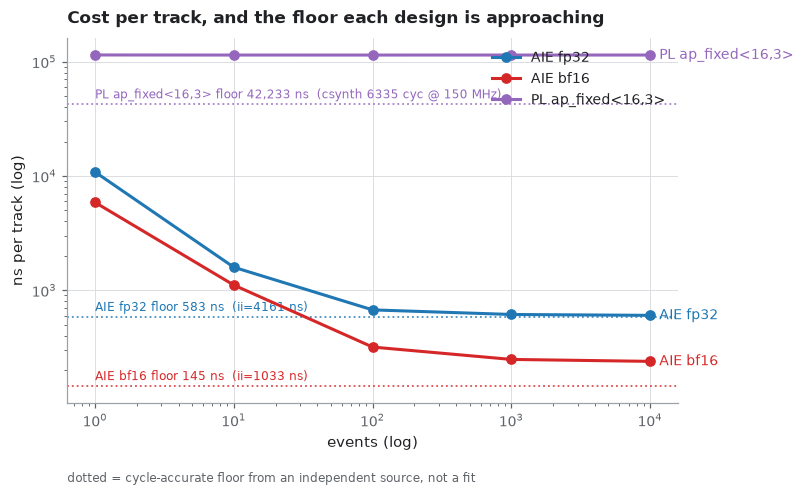


  AIE fp32                 10,839 ns/track at      1 event(s)  ->         603 at  10000   (18.0x better)
  AIE bf16                  5,872 ns/track at      1 event(s)  ->         239 at  10000   (24.6x better)
  PL ap_fixed<16,3>       114,577 ns/track at      1 event(s)  ->     114,406 at  10000   (1.0x better)


In [5]:
if not RUNS:
    print('(no data)')
else:
    fig, ax = plt.subplots(figsize=(7.2, 4.4))
    drew = False
    for r in impl_runs('hw') or impl_runs('hw_emu'):
        impl, m = r['impl'], r['meta']
        p = primary(r['df'])
        if p.empty:
            continue
        g = agg(p, 'us_execute')
        ev = g.index.to_numpy(float)
        ns = g['median'].to_numpy(float) * 1e3 / (ev * TRACKS_PER_EVENT)
        ax.plot(ev, ns, marker='o', color=COL[impl], label=LABEL[impl], zorder=3)
        ax.annotate(LABEL[impl], (ev[-1], ns[-1]), textcoords='offset points',
                    xytext=(6, 0), color=COL[impl], fontsize=9, va='center')
        drew = True

        # The asymptote each one is walking toward, from an INDEPENDENT source.
        #
        # AIE: ii_ns is the measured initiation interval per 8-track iteration,
        # and an event occupies 7 iterations for 50 real tracks -- the 6 padding
        # slots cost time but are not tracks. So ns/real track = ii * 7 / 50.
        # PL: csynth's TrackLoop latency at the linked clock.
        if impl.startswith('aie') and m.get('ii_ns'):
            asym = float(m['ii_ns']) * ITER_PER_EVENT / TRACKS_PER_EVENT
            src = f"ii={m['ii_ns']:.0f} ns"
        elif impl == 'pl_fixed':
            asym = PL_CSYNTH_US_PER_TRACK * 1e3
            src = f'csynth {PL_CSYNTH_CYCLES} cyc @ {PL_CLOCK_MHZ:.0f} MHz'
        else:
            continue
        ax.axhline(asym, color=COL[impl], ls=':', lw=1.2, alpha=0.8)
        ax.annotate(f'{LABEL[impl]} floor {asym:,.0f} ns  ({src})',
                    (ev[0], asym), textcoords='offset points', xytext=(0, 4),
                    color=COL[impl], fontsize=8)

    if drew:
        ax.set_xscale('log'); ax.set_yscale('log')
        style(ax, 'Cost per track, and the floor each design is approaching',
              'events (log)', 'ns per track (log)',
              'dotted = cycle-accurate floor from an independent source, not a fit')
        ax.legend(loc='upper right')
        save(fig, 'scan_ns_per_track.png'); plt.show()

        print()
        for r in impl_runs('hw') or impl_runs('hw_emu'):
            p = primary(r['df'])
            if p.empty:
                continue
            g = agg(p, 'us_execute')
            ev = g.index.to_numpy(float)
            ns = g['median'].to_numpy(float) * 1e3 / (ev * TRACKS_PER_EVENT)
            print(f"  {LABEL[r['impl']]:<20s} {ns[0]:>10,.0f} ns/track at "
                  f"{int(ev[0]):>6d} event(s)  ->  {ns[-1]:>10,.0f} at "
                  f"{int(ev[-1]):>6d}   ({ns[0]/ns[-1]:.1f}x better)")

## 3. Where the time goes

**Read the AIE columns with care.** Input DMA, compute and output DMA overlap by
design there — the graph consumes `x` as it arrives, and waiting on the input
transfer before `graph.run()` deadlocks because nothing drains the shim DMA until
the graph is running. So for the AIE, `us_h2d` is the cost of *issuing* the two
async transfers and `us_d2h` is the un-overlapped *tail* after `graph.wait()`.
Only the PL design, which is memory-mapped and synchronous, has genuine per-phase
transfer numbers.

`us_stage` is host-side in both: slot padding and the bf16 conversion for the AIE,
the strided repack for the PL. It is not device time and no hardware change
touches it.

  wrote analysis/out/scan_phases.png


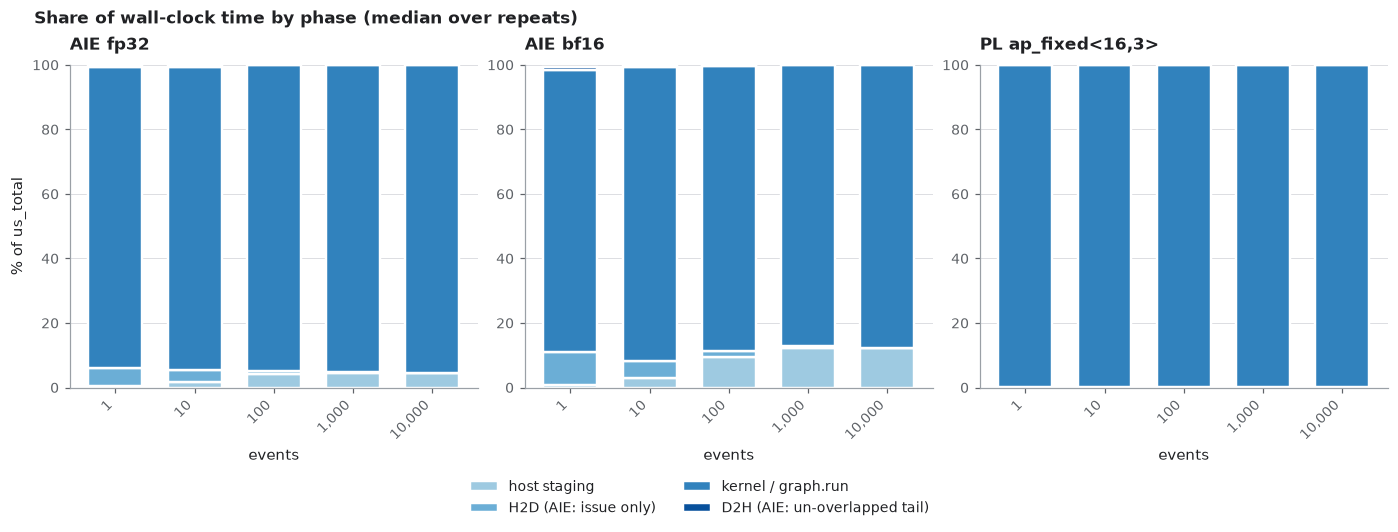


Absolute medians, us:

  AIE fp32 / hw
        us_stage  us_h2d  us_kernel  us_d2h  us_execute  us_total
events                                                           
1            2.5    30.3      508.8     3.4       541.9     544.7
10          15.1    28.2      764.2     2.9       794.8     813.2
100        148.6    32.0     3330.7     3.6      3366.2    3515.4
1000      1443.4    81.0    30600.4     7.5     30687.7   32166.0
10000    14122.0    83.0   301393.7     7.4    301482.4  315610.9

  AIE bf16 / hw
        us_stage  us_h2d  us_kernel  us_d2h  us_execute  us_total
events                                                           
1            2.4    30.3      258.8     2.9       293.6     296.5
10          17.7    29.2      522.4     3.2       554.8     572.7
100        168.5    32.9     1555.0     3.9      1591.6    1760.6
1000      1721.4    78.2    12322.5     6.5     12405.5   14140.9
10000    16731.3    84.2   119204.6     7.2    119296.3  136203.9

  PL ap_fixed<16,3

In [6]:
if not RUNS:
    print('(no data)')
else:
    present = impl_runs('hw') or impl_runs('hw_emu')
    fig, axes = plt.subplots(1, max(1, len(present)), figsize=(4.2 * max(1, len(present)), 4.2),
                             squeeze=False)
    for axi, r in zip(axes[0], present):
        impl = r['impl']
        p = primary(r['df'])
        if p.empty:
            axi.set_axis_off(); continue
        ev = sorted(p['events'].unique())
        x = np.arange(len(ev), dtype=float)
        bottom = np.zeros(len(ev))
        for ph in PHASES:
            med = np.array([p[p['events'] == e][ph].median() for e in ev], float)
            tot = np.array([p[p['events'] == e]['us_total'].median() for e in ev], float)
            frac = 100.0 * med / np.where(tot > 0, tot, np.nan)
            # 1.6px white edge = the 2px surface gap between stacked segments, so
            # adjacent fills never touch and read as one block.
            axi.bar(x, frac, bottom=bottom, width=0.68, color=PHASE_COL[ph],
                    edgecolor='white', linewidth=1.6,
                    label=PHASE_LABEL[ph] if r is present[0] else None)
            bottom += np.nan_to_num(frac)
        axi.set_xticks(x)
        axi.set_xticklabels([f'{int(e):,}' for e in ev], rotation=45, ha='right')
        axi.set_ylim(0, 100)
        axi.grid(axis='x', visible=False)
        style(axi, LABEL[impl], 'events', '% of us_total' if r is present[0] else None)
    fig.legend(loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.13))
    fig.suptitle('Share of wall-clock time by phase (median over repeats)',
                 x=0.02, ha='left', fontsize=11, fontweight='bold')
    save(fig, 'scan_phases.png'); plt.show()

    print()
    print('Absolute medians, us:')
    for r in present:
        p = primary(r['df'])
        if p.empty:
            continue
        t = p.groupby('events')[PHASES + ['us_execute', 'us_total']].median().round(1)
        print()
        print(f"  {LABEL[r['impl']]} / {r['target']}")
        print(t.to_string())

## 4. What the overhead actually is

Two different quantities, so two panels rather than one chart pretending they are
comparable:

- **AIE** — `us_modelled = ii_ns x iterations` is the array's own time, from the
  measured initiation interval. `us_execute - us_modelled` is everything else:
  the per-`graph.run()` round trip and the GMIO arming. This is a subtraction
  against a number the design itself supplies.
- **PL** — there is no equivalent runtime figure, so the comparison is against
  csynth: 6335 cycles per track at 150 MHz = 2.11 ms per 50-track event.

  wrote analysis/out/scan_overhead.png


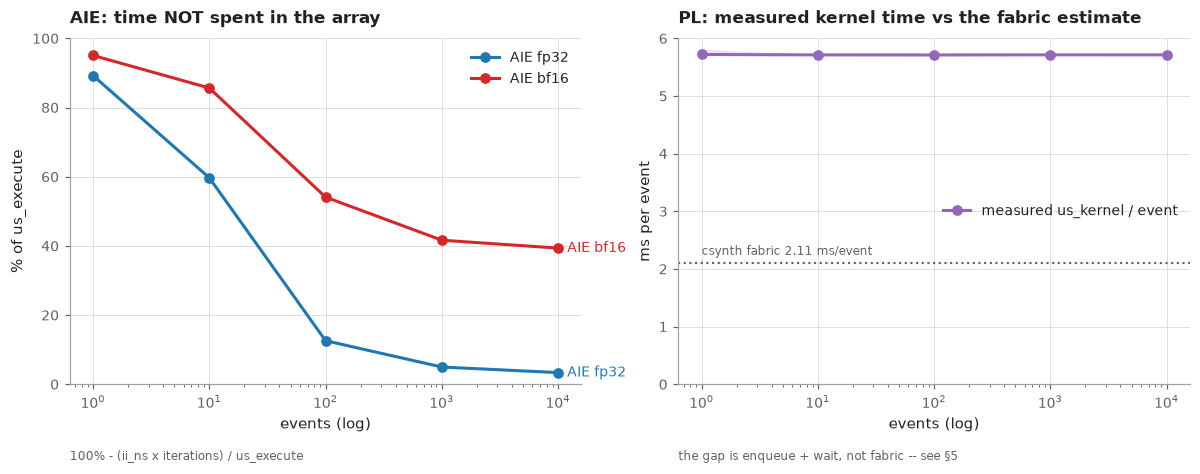

In [7]:
if not RUNS:
    print('(no data)')
else:
    aie = [r for r in (impl_runs('hw') or impl_runs('hw_emu')) if r['impl'].startswith('aie')]
    pl  = [r for r in (impl_runs('hw') or impl_runs('hw_emu')) if r['impl'] == 'pl_fixed']
    npan = (1 if aie else 0) + (1 if pl else 0)
    if npan == 0:
        print('(nothing to attribute)')
    else:
        fig, axes = plt.subplots(1, npan, figsize=(5.4 * npan, 4.2), squeeze=False)
        k = 0
        if aie:
            axi = axes[0][k]; k += 1
            for r in aie:
                p = primary(r['df'])
                if p.empty or 'us_modelled' not in p:
                    continue
                g = p.groupby('events')[['us_execute', 'us_modelled']].median()
                ev = g.index.to_numpy(float)
                pct = 100.0 * (g['us_execute'] - g['us_modelled']) / g['us_execute']
                axi.plot(ev, pct, marker='o', color=COL[r['impl']], label=LABEL[r['impl']])
                axi.annotate(LABEL[r['impl']], (ev[-1], pct.to_numpy()[-1]),
                             textcoords='offset points', xytext=(6, 0),
                             color=COL[r['impl']], fontsize=9, va='center')
            axi.set_xscale('log'); axi.set_ylim(0, 100)
            style(axi, 'AIE: time NOT spent in the array',
                  'events (log)', '% of us_execute',
                  '100% - (ii_ns x iterations) / us_execute')
            axi.legend(loc='upper right')
        if pl:
            axi = axes[0][k]
            for r in pl:
                p = primary(r['df'])
                if p.empty:
                    continue
                g = agg(p, 'us_kernel')
                ev = g.index.to_numpy(float)
                per_ev = g['median'].to_numpy(float) / ev / 1e3      # ms per event
                axi.plot(ev, per_ev, marker='o', color=COL['pl_fixed'],
                         label='measured us_kernel / event')
                axi.fill_between(ev, g['min'] / ev / 1e3, g['max'] / ev / 1e3,
                                 color=COL['pl_fixed'], alpha=0.18, lw=0)
            csynth_ms = PL_CSYNTH_US_PER_TRACK * TRACKS_PER_EVENT / 1e3
            axi.axhline(csynth_ms, color='#5f6368', ls=':', lw=1.4)
            axi.annotate(f'csynth fabric {csynth_ms:.2f} ms/event',
                         (ev[0], csynth_ms), textcoords='offset points',
                         xytext=(0, 5), fontsize=8, color='#5f6368')
            axi.set_xscale('log'); axi.set_ylim(bottom=0)
            style(axi, 'PL: measured kernel time vs the fabric estimate',
                  'events (log)', 'ms per event',
                  'the gap is enqueue + wait, not fabric -- see §5')
            axi.legend(loc='center right')
        save(fig, 'scan_overhead.png'); plt.show()

## 5. Throughput

`2 x 264,192 MAC/track` at the measured rate, against each design's own ceiling.
The AIE ceiling is its atom: `2 x 264,192 x 8 tracks / ii_ns`.

  wrote analysis/out/scan_throughput.png


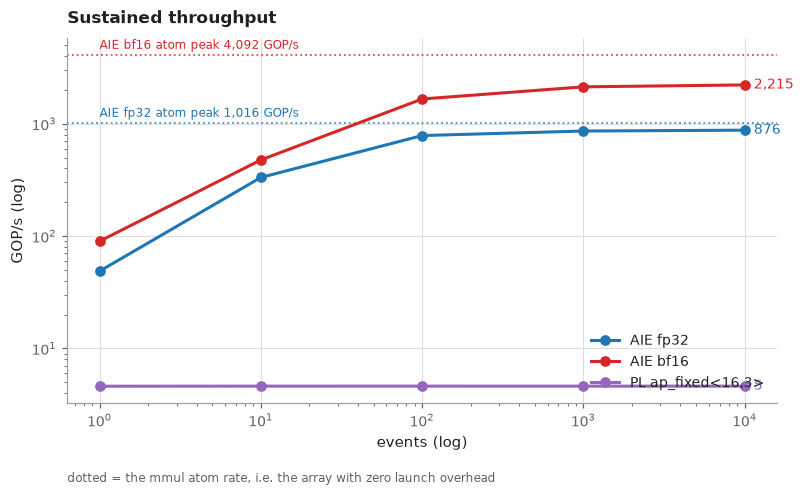

In [8]:
if not RUNS:
    print('(no data)')
else:
    fig, ax = plt.subplots(figsize=(7.2, 4.4))
    drew = False
    for r in impl_runs('hw') or impl_runs('hw_emu'):
        impl, m = r['impl'], r['meta']
        p = primary(r['df'])
        if p.empty:
            continue
        g = agg(p, 'us_execute')
        ev = g.index.to_numpy(float)
        gops = (OPS_PER_MAC * MACS_PER_TRACK * ev * TRACKS_PER_EVENT
                / (g['median'].to_numpy(float) * 1e-6) / 1e9)
        ax.plot(ev, gops, marker='o', color=COL[impl], label=LABEL[impl], zorder=3)
        ax.annotate(f'{gops[-1]:,.0f}', (ev[-1], gops[-1]), textcoords='offset points',
                    xytext=(6, 0), color=COL[impl], fontsize=9, va='center')
        drew = True
        if impl.startswith('aie') and m.get('ii_ns'):
            peak = OPS_PER_MAC * MACS_PER_TRACK * BATCH / (float(m['ii_ns']) * 1e-9) / 1e9
            ax.axhline(peak, color=COL[impl], ls=':', lw=1.2, alpha=0.8)
            ax.annotate(f'{LABEL[impl]} atom peak {peak:,.0f} GOP/s',
                        (ev[0], peak), textcoords='offset points', xytext=(0, 4),
                        color=COL[impl], fontsize=8)
    if drew:
        ax.set_xscale('log'); ax.set_yscale('log')
        style(ax, 'Sustained throughput', 'events (log)', 'GOP/s (log)',
              'dotted = the mmul atom rate, i.e. the array with zero launch overhead')
        ax.legend(loc='lower right')
        save(fig, 'scan_throughput.png'); plt.show()

## 6. The PL bottleneck — per-call overhead, or slow fabric?

`n_tracks` is a runtime `s_axilite` argument and `TrackLoop` is
`for (j = 0; j < n_tracks; j++)`, so one kernel call can process 50, 100, 500 or
1000 tracks. Fitting `us_call = fixed + marginal x tracks` over that sweep
separates the two candidate explanations, and they predict very different numbers:

| if marginal is | then | and |
|---|---|---|
| ≈ 42 us/track | csynth is right; the gap is **per-call driver cost** | batching events into one call fixes it |
| ≈ 114 us/track | the **fabric is slower** than csynth predicted, or the achieved clock is below 150 MHz | batching will not help |

The 128-wide mean is meaningless for `n_tracks != 50` — the accumulator divides by
the event size — which is why these rows carry `mode=tpc` and are never plotted as
event throughput.

  wrote analysis/out/scan_pl_calls_hw.png


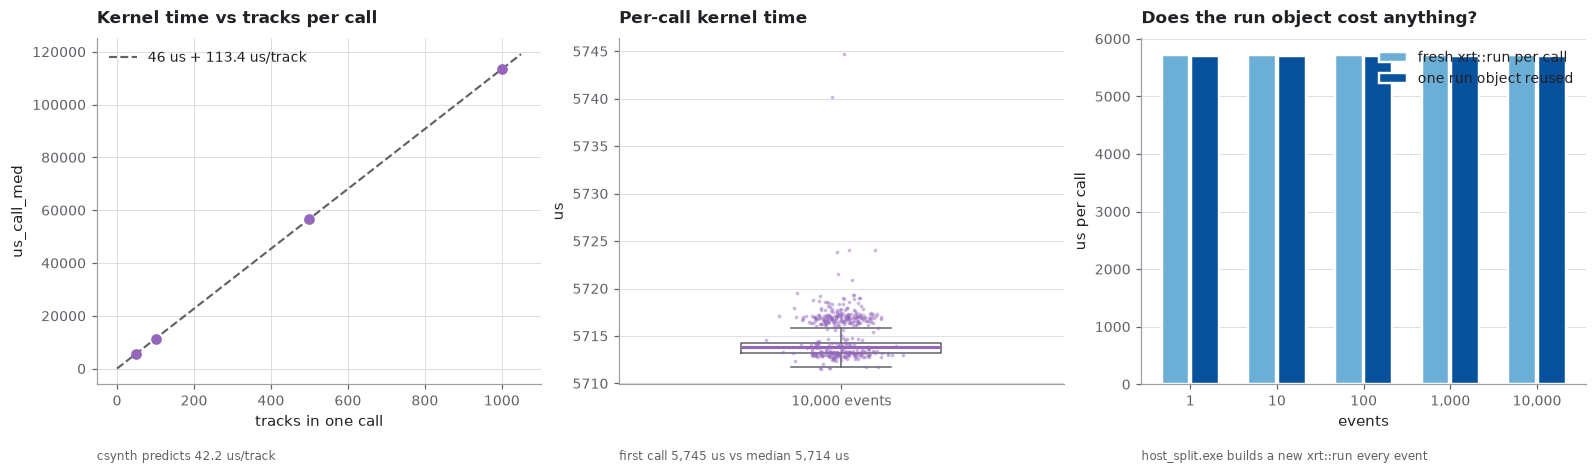


 tracks_per_call  launches  us_call_min  us_call_med  us_call_max
              50        20     5711.955    5716.5600     5774.455
             100        20    11381.590   11386.8900    11389.610
             500        20    56742.230   56747.0505    56769.040
            1000        20   113443.460  113448.6800   113462.151

  fit: us_call = 46.5 us + 113.40 us/track
  csynth       = 42.23 us/track (6335 cycles @ 150 MHz)
  -> the bottleneck is the fabric itself -- batching will not help


In [9]:
pl = [r for r in RUNS if r['impl'] == 'pl_fixed']
if not pl:
    print('(no PL scan)')
else:
    for r in pl:
        d = r['df']
        tpc = d[d['mode'] == 'tpc'].sort_values('tracks_per_call')
        fresh = d[d['mode'] == 'fresh']
        reuse = d[d['mode'] == 'reuse']

        panels = int(not tpc.empty) + int(bool(r['calls'])) + int(not reuse.empty)
        if panels == 0:
            print(f"  {r['target']}: no PL diagnostics in this run")
            continue
        fig, axes = plt.subplots(1, panels, figsize=(4.8 * panels, 4.2), squeeze=False)
        k = 0

        # ---- the fit -------------------------------------------------------
        if not tpc.empty:
            axi = axes[0][k]; k += 1
            n = tpc['tracks_per_call'].to_numpy(float)
            y = tpc['us_call_med'].to_numpy(float)
            axi.plot(n, y, marker='o', color=COL['pl_fixed'], ls='none', zorder=3)
            axi.fill_between(n, tpc['us_call_min'], tpc['us_call_max'],
                             color=COL['pl_fixed'], alpha=0.18, lw=0)
            if len(n) >= 2:
                A = np.column_stack([np.ones_like(n), n])
                (fixed, marginal), *_ = np.linalg.lstsq(A, y, rcond=None)
                xs = np.linspace(0, n.max() * 1.05, 50)
                axi.plot(xs, fixed + marginal * xs, color='#5f6368', lw=1.4, ls='--',
                         label=f'{fixed:,.0f} us + {marginal:.1f} us/track')
                axi.axhline(0, color='#dadce0', lw=0.6)
                axi.legend(loc='upper left')
                verdict = ('per-call driver overhead -- batching would fix it'
                           if marginal < 0.5 * (PL_CSYNTH_US_PER_TRACK +
                                                y[0] / TRACKS_PER_EVENT)
                           else 'the fabric itself -- batching will not help')
            else:
                fixed = marginal = float('nan'); verdict = 'need >= 2 tpc points'
            style(axi, 'Kernel time vs tracks per call', 'tracks in one call',
                  'us_call_med',
                  f'csynth predicts {PL_CSYNTH_US_PER_TRACK:.1f} us/track')

        # ---- the distribution ---------------------------------------------
        if r['calls']:
            axi = axes[0][k]; k += 1
            ev = max(r['calls'])
            s = r['calls'][ev]['us_kernel'].to_numpy(float)
            axi.boxplot([s], widths=0.45, vert=True, showfliers=False,
                        medianprops=dict(color=COL['pl_fixed'], lw=2),
                        boxprops=dict(color='#5f6368'),
                        whiskerprops=dict(color='#5f6368'),
                        capprops=dict(color='#5f6368'))
            axi.plot(np.full(min(len(s), 400), 1.0) +
                     np.random.default_rng(0).normal(0, 0.045, min(len(s), 400)),
                     s[:400], '.', ms=3, color=COL['pl_fixed'], alpha=0.35)
            axi.set_xticks([1]); axi.set_xticklabels([f'{ev:,} events'])
            axi.grid(axis='x', visible=False)
            style(axi, 'Per-call kernel time', None, 'us',
                  f'first call {s[0]:,.0f} us vs median {np.median(s):,.0f} us')

        # ---- fresh vs reuse ------------------------------------------------
        if not reuse.empty:
            axi = axes[0][k]
            ev = sorted(set(fresh['events']) & set(reuse['events']))
            x = np.arange(len(ev), dtype=float)
            for off, (sub, name, c) in enumerate((
                    (fresh, 'fresh xrt::run per call', '#6baed6'),
                    (reuse, 'one run object reused', '#08519c'))):
                v = [sub[sub['events'] == e]['us_call_med'].median() for e in ev]
                axi.bar(x + (off - 0.5) * 0.34, v, width=0.32, color=c,
                        edgecolor='white', linewidth=1.6, label=name)
            axi.set_xticks(x); axi.set_xticklabels([f'{int(e):,}' for e in ev])
            axi.grid(axis='x', visible=False)
            axi.legend(loc='upper right')
            style(axi, 'Does the run object cost anything?', 'events',
                  'us per call',
                  'host_split.exe builds a new xrt::run every event')
        save(fig, f"scan_pl_calls_{r['target']}.png"); plt.show()

        if not tpc.empty and len(tpc) >= 2:
            print()
            print(tpc[['tracks_per_call', 'launches', 'us_call_min', 'us_call_med',
                       'us_call_max']].to_string(index=False))
            print()
            print(f'  fit: us_call = {fixed:,.1f} us + {marginal:.2f} us/track')
            print(f'  csynth       = {PL_CSYNTH_US_PER_TRACK:.2f} us/track '
                  f'({PL_CSYNTH_CYCLES} cycles @ {PL_CLOCK_MHZ:.0f} MHz)')
            print(f'  -> the bottleneck is {verdict}')

## 7. The AIE launch cost, measured directly

The same event count split across N `graph.run()` calls, each with its own flush
event and its own offset into the same pair of BOs. If the fixed cost is really
per-launch, splitting 1000 events into 10 launches should add 9 x that cost and
nothing else — which turns an inferred intercept into a measurement.

  wrote analysis/out/scan_launches.png


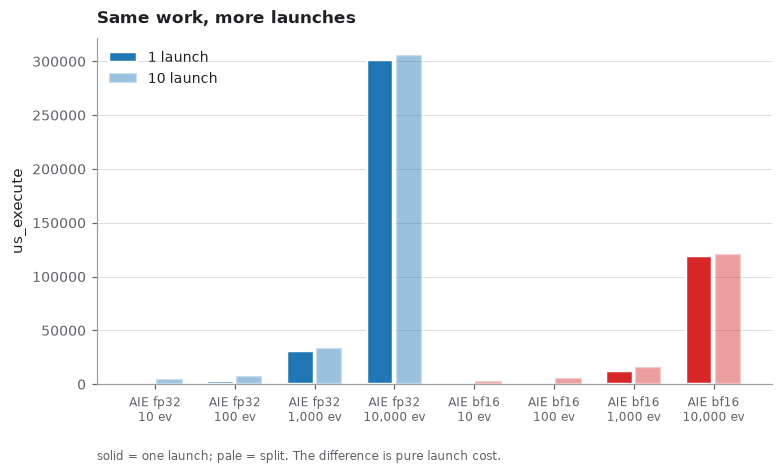


    impl  events  us, 1 launch  us, 10 launches  implied us per extra launch
AIE fp32      10         794.8           5294.0                        499.9
AIE fp32     100        3366.2           7869.4                        500.4
AIE fp32    1000       30687.7          33669.0                        331.3
AIE fp32   10000      301482.4         306046.7                        507.1
AIE bf16      10         554.8           2779.1                        247.1
AIE bf16     100        1591.6           5415.6                        424.9
AIE bf16    1000       12405.5          15785.9                        375.6
AIE bf16   10000      119296.3         121314.1                        224.2

  Compare "implied us per extra launch" with the fixed term of the
  §2 fit. Two independent routes to the same number agreeing is
  what makes it a measurement rather than an artefact of one method.


In [10]:
aie = [r for r in RUNS if r['impl'].startswith('aie')]
if not aie:
    print('(no AIE scan)')
else:
    rows, drew = [], False
    fig, ax = plt.subplots(figsize=(7.0, 4.2))
    width = 0.36
    labels = []
    for i, r in enumerate(aie):
        d = primary(r['df']) if False else r['df'][r['df']['mode'] == 'gmio']
        splits = sorted(d['launches'].unique())
        if len(splits) < 2:
            continue
        ev_common = sorted(set.intersection(*[set(d[d['launches'] == s]['events'])
                                              for s in splits]))
        for e in ev_common:
            sub = d[d['events'] == e]
            base = sub[sub['launches'] == splits[0]]['us_execute'].median()
            for j, s in enumerate(splits):
                v = sub[sub['launches'] == s]['us_execute'].median()
                pos = len(labels) + (j - (len(splits) - 1) / 2) * width
                ax.bar(pos, v, width=width * 0.92,
                       color=COL[r['impl']], alpha=1.0 if s == splits[0] else 0.45,
                       edgecolor='white', linewidth=1.6,
                       label=(f'{s} launch' if len(labels) == 0 else None))
                if s != splits[0]:
                    per = (v - base) / (s - splits[0])
                    rows.append({'impl': LABEL[r['impl']], 'events': int(e),
                                 f'us, {splits[0]} launch': round(base, 1),
                                 f'us, {s} launches': round(v, 1),
                                 'implied us per extra launch': round(per, 1)})
            labels.append(f"{LABEL[r['impl']]}\n{int(e):,} ev")
            drew = True
    if drew:
        ax.set_xticks(np.arange(len(labels))); ax.set_xticklabels(labels, fontsize=8)
        ax.grid(axis='x', visible=False)
        ax.legend(loc='upper left')
        style(ax, 'Same work, more launches', None, 'us_execute',
              'solid = one launch; pale = split. The difference is pure launch cost.')
        save(fig, 'scan_launches.png'); plt.show()
        print()
        print(pd.DataFrame(rows).to_string(index=False))
        print()
        print('  Compare "implied us per extra launch" with the fixed term of the')
        print('  §2 fit. Two independent routes to the same number agreeing is')
        print('  what makes it a measurement rather than an artefact of one method.')
    else:
        print('(only one launch count in this scan -- set RTDA_SCAN_SPLITS=1,10)')

## 8. Summary

In [11]:
if not RUNS:
    print('(no data)')
else:
    summary = []
    for r in impl_runs('hw') or impl_runs('hw_emu'):
        impl, m = r['impl'], r['meta']
        p = primary(r['df'])
        if p.empty:
            continue
        g = agg(p, 'us_execute')
        ev_lo, ev_hi = g.index.min(), g.index.max()
        lo, hi = g.loc[ev_lo], g.loc[ev_hi]
        ns_hi = hi['median'] * 1e3 / (ev_hi * TRACKS_PER_EVENT)
        gops_hi = (OPS_PER_MAC * MACS_PER_TRACK * ev_hi * TRACKS_PER_EVENT
                   / (hi['median'] * 1e-6) / 1e9)
        summary.append({
            'implementation': LABEL[impl],
            'source': r['target'],
            'reps': int(hi['count']),
            f'ns/track @{int(ev_lo)}ev': round(lo['median'] * 1e3 / (ev_lo * TRACKS_PER_EVENT), 1),
            f'ns/track @{int(ev_hi)}ev': round(ns_hi, 1),
            'spread @max %': round(100 * (hi['max'] - hi['min']) / hi['median'], 1),
            'GOP/s @max': round(gops_hi, 1),
            'once: xclbin open ms': round(float(m.get('us_xclbin_open') or 0) / 1e3, 1),
            'once: RTP load ms': round(float(m.get('us_rtp_load') or 0) / 1e3, 1),
        })
    S = pd.DataFrame(summary)
    print(S.to_string(index=False))

    S.to_csv(OUTD / 'scan_summary.csv', index=False)
    print()
    print('  wrote', (OUTD / 'scan_summary.csv').relative_to(REPO))

    # ---- the report --------------------------------------------------------
    # Written to a file, not just printed, so the result exists outside a
    # notebook that has to be re-run to be read.
    L = []
    L.append('# RTDA performance scan\n')
    srcs = sorted({r['target'] for r in RUNS})
    L.append(f"Generated by `analysis/rtda_scan.ipynb`. Source: {', '.join(srcs)}.\n")
    for r in RUNS:
        m = r['meta']
        L.append(f"- **{LABEL[r['impl']]}** ({r['target']}): `{m.get('xclbin','?')}`, "
                 f"{m.get('reps','?')} repeats, stimulus {m.get('stimulus_events','?')} "
                 f"events, rev `{m.get('git_hash','?')}`, {m.get('date_utc','?')}")
    L.append('\n## Headline\n')
    L.append(md_table(S))
    L.append('\n## Scaling fits\n')
    L.append('`us_execute = fixed + marginal x tracks`. The fixed term is paid once '
             'per invocation and is host/driver side; the marginal term is what the '
             'design costs per track.\n')
    for r in impl_runs('hw') or impl_runs('hw_emu'):
        p = primary(r['df'])
        if p.empty or p['events'].nunique() < 2:
            continue
        g = agg(p, 'us_execute')
        tr = g.index.to_numpy(float) * TRACKS_PER_EVENT
        A = np.column_stack([np.ones_like(tr), tr])
        (fx, mg), *_ = np.linalg.lstsq(A, g['median'].to_numpy(float), rcond=None)
        L.append(f"- **{LABEL[r['impl']]}**: {fx:,.1f} us fixed + {mg*1e3:,.1f} ns/track")
    pl = [r for r in RUNS if r['impl'] == 'pl_fixed']
    if pl:
        t = pl[0]['df']
        t = t[t['mode'] == 'tpc'].sort_values('tracks_per_call')
        if len(t) >= 2:
            n = t['tracks_per_call'].to_numpy(float)
            y = t['us_call_med'].to_numpy(float)
            A = np.column_stack([np.ones_like(n), n])
            (fx, mg), *_ = np.linalg.lstsq(A, y, rcond=None)
            L.append('\n## The PL bottleneck\n')
            L.append(f'- fit over tracks-per-call: **{fx:,.1f} us fixed per call + '
                     f'{mg:.2f} us/track**')
            L.append(f'- csynth predicts {PL_CSYNTH_US_PER_TRACK:.2f} us/track '
                     f'({PL_CSYNTH_CYCLES} cycles @ {PL_CLOCK_MHZ:.0f} MHz)')
    L.append('\n## Caveats\n')
    L.append('- The AIE has **no H2D/D2H split**: input DMA, compute and output DMA '
             'overlap by design, so `us_h2d` is an issue cost and `us_d2h` an '
             'un-overlapped tail. Only the PL numbers are real per-phase transfers.')
    L.append('- `mean_checksum` is a smoke value, not accuracy. Accuracy lives in '
             '`analysis/rtda_compare.ipynb`.')
    L.append('- Not measured: power, DDR bandwidth ceiling, multi-CU scaling.')
    L.append('- `mode=tpc` rows are timing only -- the 128-wide mean is not an event '
             'mean at those track counts.')
    (OUTD / 'scan_report.md').write_text('\n'.join(L) + '\n')
    print('  wrote', (OUTD / 'scan_report.md').relative_to(REPO))

   implementation source  reps  ns/track @1ev  ns/track @10000ev  spread @max %  GOP/s @max  once: xclbin open ms  once: RTP load ms
         AIE fp32     hw     5        10838.6              603.0            0.1       876.3                 231.2                5.6
         AIE bf16     hw     5         5872.0              238.6            0.2      2214.6                 231.2                4.7
PL ap_fixed<16,3>     hw     5       114576.7           114405.7            0.0         4.6                 180.4                0.0

  wrote analysis/out/scan_summary.csv
  wrote analysis/out/scan_report.md


## What this notebook does not measure

- **Power.** `pl_fixed/plot_power.py` and the `*.csv` beside it are a separate,
  older measurement.
- **The DDR bandwidth ceiling.** Buffers here are tens of MB and the transfers are
  not the limit at any point in this sweep, but nothing above proves that.
- **Multi-CU or multi-graph scaling.** One CU, one graph, one at a time.
- **The AIE H2D/D2H split**, which is structurally unavailable — see §3.
- **Accuracy.** Deliberately: `mean_checksum` catches a dead device and nothing
  more. `analysis/rtda_compare.ipynb` owns correctness, against the ONNX
  reference, with the warm-up convention handled properly.